# Logistic Regression

Linear Regression을 가지고 classfy하는 알고리즘

## Sigmoid 함수 (활성화 함수)

output을 0-1 사이의 확률로 변환하는 S자 곡선. 선형식 z를 확률로 바꿔줌

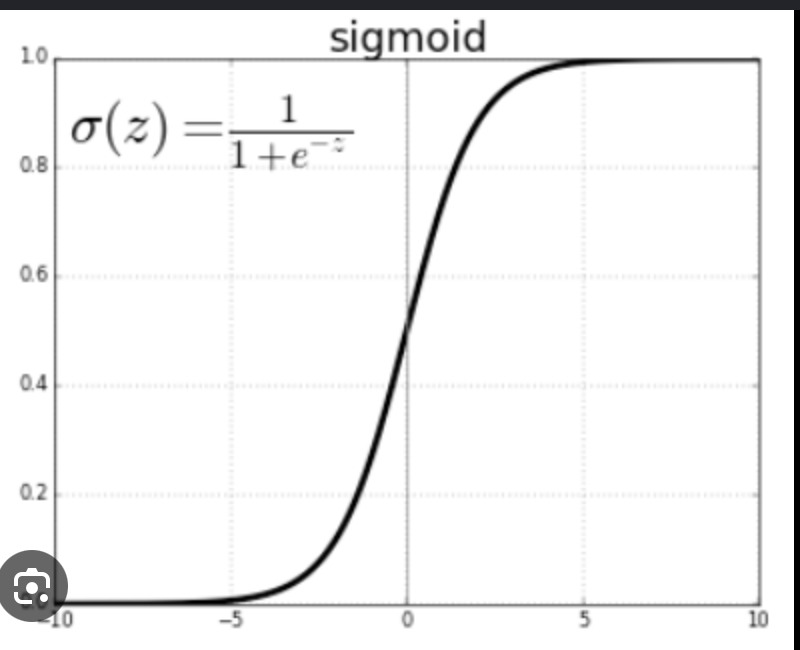

포물선이 아니기 때문에, 경사하강법 사용 불가.

MSE (Mean Squared Error) 말고

### Binary Cross Etropy 사용

binary cross entropy 값이 최소화하도록 함.

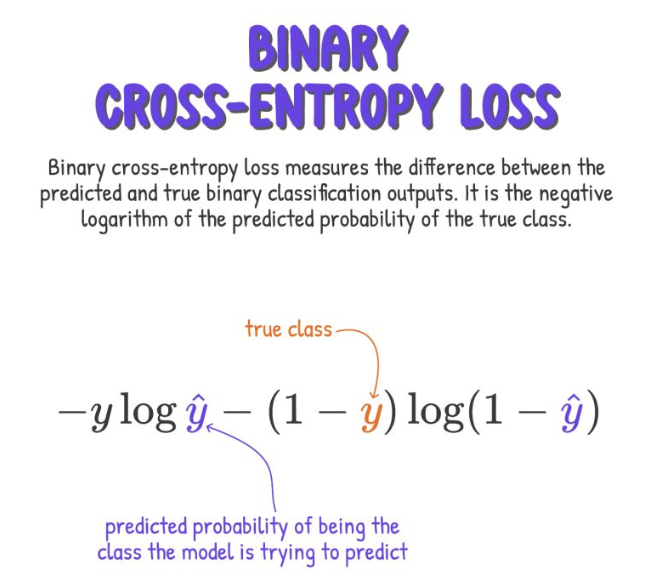

# 다중분류 Multiclass Classification

이진분류 여러개를 나란히 두고, 각자의 확률을 출력함.


각 이진분류의 결과가 logit. 시그모이드에 logit을 넣으면 확률이 나옴. BUT 확률들을 더하면 1이 넘는 경우가 발생.

따라서 시그모이드 함수를 Softmax 함수로 바꿈.

logit값을 다 더한게 분모, 그중 원하는 logit을 분자에 올리기.

## Softmax

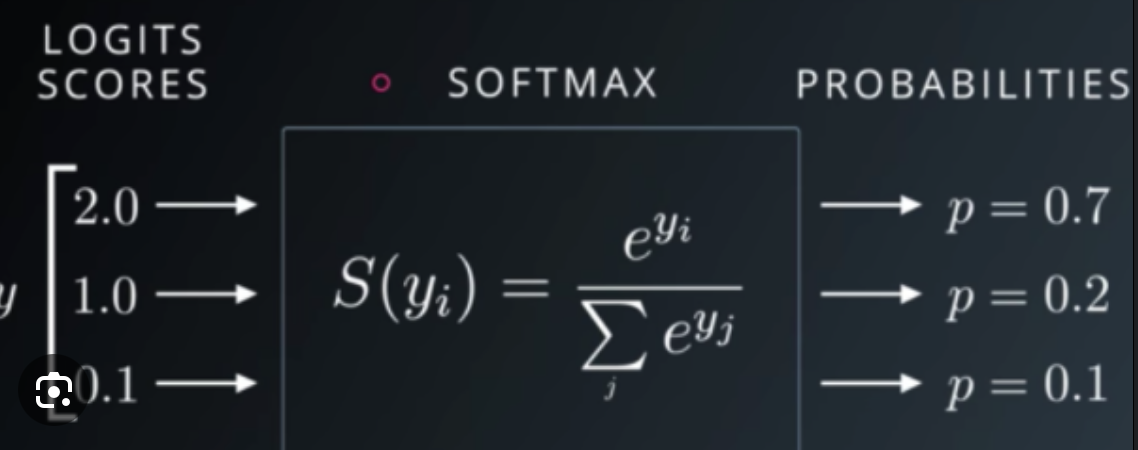

## 다중분류일때는 Categorical Cross Entropy 사용.

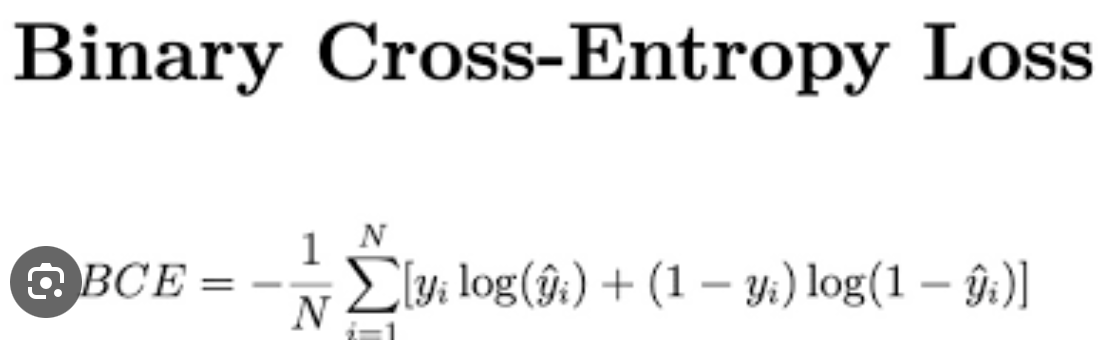

# 실습

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 데이터 읽어오기

In [ ]:
diabetes = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/diabetes.csv')

In [ ]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Train, Validation, Test 나누기

In [ ]:
from sklearn.model_selection import train_test_split


train, test = train_test_split(diabetes, test_size=0.2, random_state=SEED, stratify=diabetes['Outcome'], shuffle=True)
x_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']

## 데이터 전처리

In [ ]:
temp_cols = ['BMI', 'Insulin', 'SkinThickness', 'BloodPressure', 'Glucose']

x_train[temp_cols] = x_train[temp_cols].replace(0, np.nan)

mean_values = {}
for col in temp_cols:
  u = x_train[col].mean()
  x_train[col] = x_train[col].fillna(u)
  mean_values[col] = u

### Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)

y_train = y_train.to_numpy()

## 모델 학습 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [ ]:
clf = LogisticRegression(random_state=SEED)
param_grid = {
        'solver' : ['lbfgs', 'liblinear', 'newton-cg']}


grid = GridSearchCV(clf, param_grid, cv=3, verbose=1, n_jobs=-1)
grid.fit(x_train_s, y_train)

best_clf = grid.best_estimator_

Fitting 3 folds for each of 3 candidates, totalling 9 fits


## 테스트

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred)     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred)    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred)       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

1. Accuracy: 0.6948
2. Recall: 0.4815
3. Precision: 0.5778
4. F1 Score: 0.5253


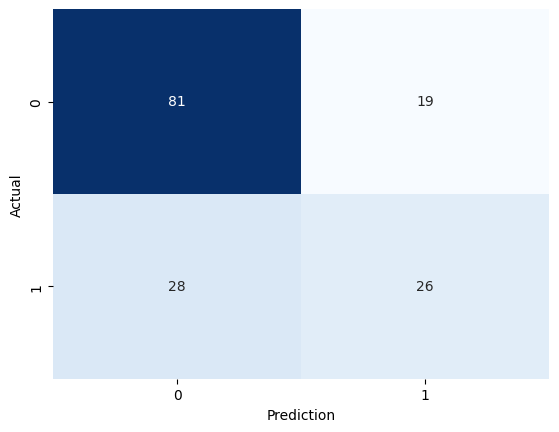

In [ ]:
x_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']

x_test[temp_cols] = x_test[temp_cols].replace(0, np.nan)
for col in temp_cols:
    x_test[col] = x_test[col].fillna(mean_values[col])


x_test_s = scaler.transform(x_test)
y_test = y_test.to_numpy()


y_predict = best_clf.predict(x_test_s)

print_metrics(y_test, y_predict)